# DATA CLEANING

In [165]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

In [187]:
df = sns.load_dataset("titanic")

In [188]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [189]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [190]:
df.duplicated().sum()

np.int64(107)

In [191]:
df.drop_duplicates(inplace=True)

In [192]:
(df.isnull().sum()/len(df))*100

survived        0.000000
pclass          0.000000
sex             0.000000
age            13.520408
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.255102
class           0.000000
who             0.000000
adult_male      0.000000
deck           74.234694
embark_town     0.255102
alive           0.000000
alone           0.000000
dtype: float64

In [193]:
print(df['age'].skew())  # right skewed so we will use median

0.3674542095476674


# Rules
### if null values > 50% drop

### if null < 50% replace it with mean ,median or mode or something

### if data - skewed - median

### if data - mornal - mean

### if data -categorical- mode 

### df['column_name'].skew()     if skew > 0 right skewed         if skew < 0 left skewed          if skew = 0 not skewed

### also remove duplicate values using df.drop_duplicates(inplace=True)

In [194]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            106
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           582
embark_town      2
alive            0
alone            0
dtype: int64

In [195]:
#1 - approach
df["age"] = df["age"].fillna(df["age"].median())
# 2 - approach 
df_numeric = df.select_dtypes(include=["number"]).columns
num_imputer = SimpleImputer(strategy="median")

In [196]:
# 1 - simple approach(single column at a time)
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])
# 2 - Simple imputer(handles all string columns at once)
df_categorical = df.select_dtypes(include=["string","category"]).columns
cat_imputer = SimpleImputer(strategy="most_frequent")
df[df_categorical]=cat_imputer.fit_transform(df[df_categorical])

In [197]:
df=df.drop(columns="deck")

In [198]:
df.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

In [199]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
le = LabelEncoder()
df["adult_male"]=le.fit_transform(df["adult_male"])
df["alone"]=le.fit_transform(df["alone"])
df["alive"]=le.fit_transform(df["alive"])


In [200]:
df.head(20)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.00,1,0,7.2500,S,Third,man,1,Southampton,0,0
1,1,1,female,38.00,1,0,71.2833,C,First,woman,0,Cherbourg,1,0
2,1,3,female,26.00,0,0,7.9250,S,Third,woman,0,Southampton,1,1
3,1,1,female,35.00,1,0,53.1000,S,First,woman,0,Southampton,1,0
4,0,3,male,35.00,0,0,8.0500,S,Third,man,1,Southampton,0,1
5,0,3,male,28.25,0,0,8.4583,Q,Third,man,1,Queenstown,0,1
6,0,1,male,54.00,0,0,51.8625,S,First,man,1,Southampton,0,1
7,0,3,male,2.00,3,1,21.0750,S,Third,child,0,Southampton,0,0
8,1,3,female,27.00,0,2,11.1333,S,Third,woman,0,Southampton,1,0
9,1,2,female,14.00,1,0,30.0708,C,Second,child,0,Cherbourg,1,0


<Axes: ylabel='fare'>

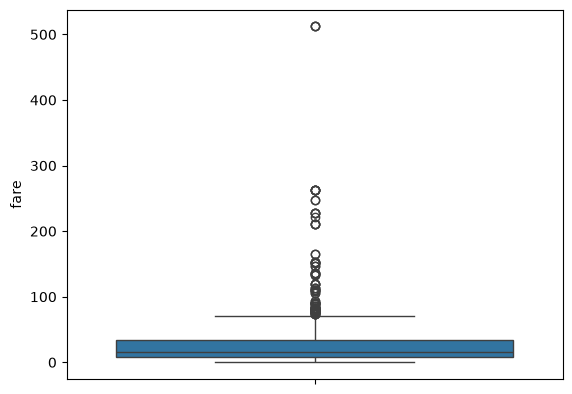

In [201]:
sns.boxplot(df["fare"])

In [202]:
q1 = df["fare"].quantile(0.25)
q3 = df["fare"].quantile(0.75)
IQR = q3-q1
lower = q1 - 1.5 * IQR
upper = q3 + 1.5 * IQR

In [203]:
#identify outliers
outliers = df[(df["fare"] >= lower) & (df["fare"] > upper)]
#remove outliers
df = df[(df["fare"] >= lower) & (df["fare"] <= upper)]

<Axes: ylabel='fare'>

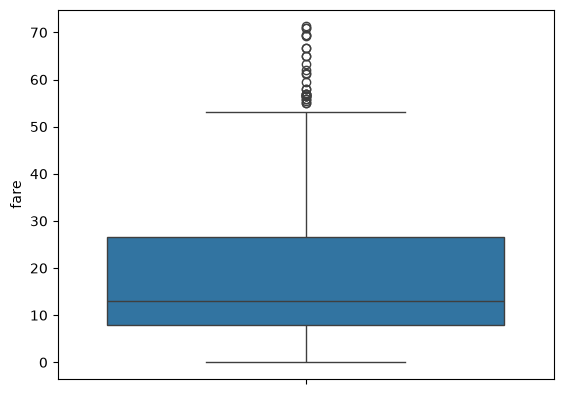

In [205]:
sns.boxplot(df["fare"])